## Principal Component Analysis (PCA).

In [2]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
%matplotlib inline

from sklearn.datasets import load_breast_cancer

In [3]:
cancer = load_breast_cancer()

In [5]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [23]:
# print(cancer['DESCR'])

In [8]:
df = pd.DataFrame(cancer.data, columns= cancer.feature_names)

In [10]:
df.sample(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
7,13.71,20.83,90.2,577.9,0.1189,0.1645,0.09366,0.05985,0.2196,0.07451,...,17.06,28.14,110.6,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.1151
258,15.66,23.20,110.2,773.5,0.1109,0.3114,0.31760,0.13770,0.2495,0.08104,...,19.85,31.64,143.7,1226.0,0.1504,0.5172,0.6181,0.2462,0.3277,0.1019


In [11]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()
scaler.fit(df)

StandardScaler()

In [14]:
scaled_data = scaler.transform(df)

In [15]:
scaled_data

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [16]:
from sklearn.decomposition import PCA

In [17]:
pca = PCA(n_components= 2)

In [18]:
pca.fit(scaled_data)

PCA(n_components=2)

In [19]:
principal_components = pca.transform(scaled_data)

In [20]:
principal_components

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

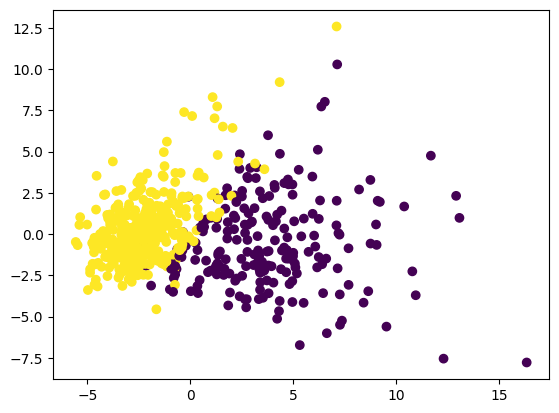

In [22]:
plt.scatter(principal_components[:, 0], principal_components[:,1], c= cancer.target);

---
## t-SNE (t-Distributed Stochastic Neighbor Embedding).

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.manifold import TSNE

In [25]:
X, y = make_blobs(n_samples= 300, centers= 4, n_features = 8, random_state= 452)

In [27]:
X.shape

(300, 8)

In [28]:
tsne = TSNE(n_components=2, perplexity= 30, n_iter= 1000, random_state= 452)
X_tsne = tsne.fit_transform(X)

C:\Users\SurajkumarYadav\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [30]:
X_tsne.shape

(300, 2)

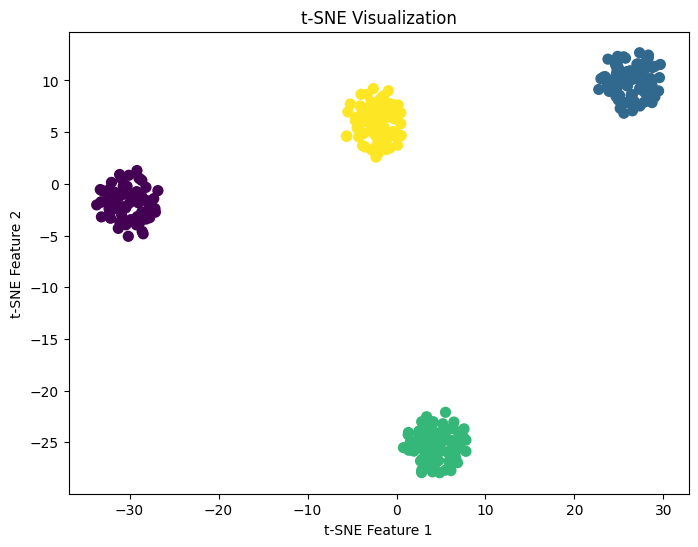

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', s=50)
# plt.colorbar(label='Cluster Label')
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Feature 1")
plt.ylabel("t-SNE Feature 2")
plt.show()

---
## PCA from Scratch.

In [36]:
df = pd.DataFrame({
    "X" : [1,4,5,22,0.5, 9, 2.2,3],
    "Y" : [3,2,1,4, 2.2, 3.4, 5, 6]
}
)

In [37]:
df

,X,Y
0,1.0,3.0
1,4.0,2.0
2,5.0,1.0
3,22.0,4.0
4,0.5,2.2
5,9.0,3.4
6,2.2,5.0
7,3.0,6.0


In [38]:
# scaling
scaler = StandardScaler()

In [39]:
scaled_data = scaler.fit_transform(df)
scaled_data

array([[-0.73295586, -0.21113803],
       [-0.27840959, -0.8607935 ],
       [-0.12689417, -1.51044897],
       [ 2.44886803,  0.43851744],
       [-0.80871357, -0.7308624 ],
       [ 0.47916753,  0.04872416],
       [-0.55113735,  1.08817291],
       [-0.42992501,  1.73782838]])

In [42]:
X = scaled_data[:,0]
Y = scaled_data[:,1]

In [43]:
## Calculating covariance matrix
cov_matrix = np.cov(X, Y)
cov_matrix

array([[1.14285714, 0.13249761],
       [0.13249761, 1.14285714]])

In [46]:
## Calculating eigenvectors and eigenvalues
eigen_values ,eigen_vectors = np.linalg.eig(cov_matrix)
print(eigen_values, "\n",eigen_vectors)

[1.27535475 1.01035953] 
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [50]:
transformed_data = np.dot(scaled_data, eigen_vectors)
new_df = pd.DataFrame(transformed_data, columns=['PC1', 'PC2'])
new_df

,PC1,PC2
0,-0.667575,0.368981
1,-0.805538,-0.411808
2,-1.157776,-0.978321
3,2.041690,-1.421533
4,-1.088645,0.055049
5,0.373276,-0.304369
6,0.379741,1.159167
7,0.924827,1.532833


Covariance Matrix:
 [[0.61655556 0.61544444]
 [0.61544444 0.71655556]]

Eigenvalues:
 [0.0490834  1.28402771]

Eigenvectors:
 [[-0.73517866 -0.6778734 ]
 [ 0.6778734  -0.73517866]]

Sorted Eigenvalues:
 [1.28402771 0.0490834 ]

Sorted Eigenvectors:
 [[-0.6778734  -0.73517866]
 [-0.73517866  0.6778734 ]]

Data projected onto the first principal component:
 [-0.82797019  1.77758033 -0.99219749 -0.27421042 -1.67580142 -0.9129491
  0.09910944  1.14457216  0.43804614  1.22382056]


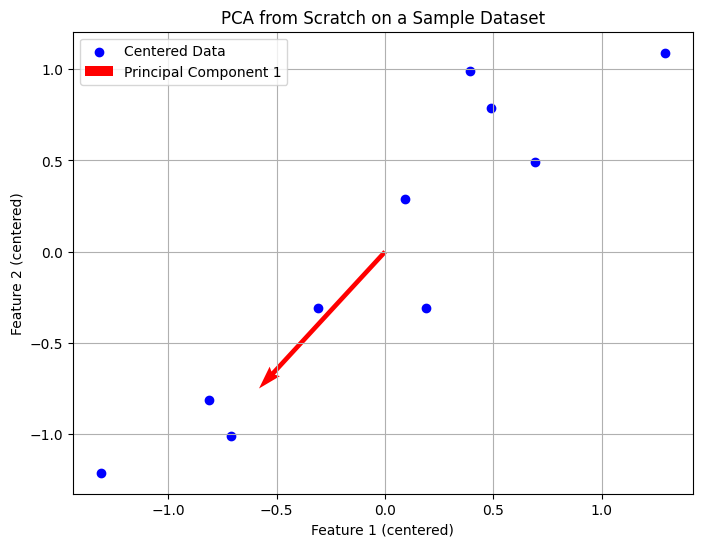

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a small sample dataset (10 samples, 2 features)
X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
])

# 2. Center the data (subtract the mean)
mean_X = np.mean(X, axis=0)
X_centered = X - mean_X

# 3. Compute the covariance matrix of the centered data
# Note: np.cov expects variables in rows, so we use X_centered.T
cov_matrix = np.cov(X_centered.T)
print("Covariance Matrix:\n", cov_matrix)

# 4. Compute eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

# 5. Sort eigenvalues and eigenvectors in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_idx]
eigenvectors_sorted = eigenvectors[:, sorted_idx]

print("\nSorted Eigenvalues:\n", eigenvalues_sorted)
print("\nSorted Eigenvectors:\n", eigenvectors_sorted)

# 6. Project the data onto the principal components
# For example, reduce to 1D using the first principal component:
PC1 = eigenvectors_sorted[:, 0]
X_pca_1d = X_centered.dot(PC1)
print("\nData projected onto the first principal component:\n", X_pca_1d)

# 7. (Optional) Visualize the original data and the principal component
plt.figure(figsize=(8, 6))
plt.scatter(X_centered[:, 0], X_centered[:, 1], color='blue', label='Centered Data')

# Plot the principal component vector
origin = [0, 0]
plt.quiver(*origin, PC1[0]*3, PC1[1]*3, color='red', scale=10, label='Principal Component 1')

plt.xlabel("Feature 1 (centered)")
plt.ylabel("Feature 2 (centered)")
plt.title("PCA from Scratch on a Sample Dataset")
plt.legend()
plt.grid(True)
plt.show()
